In [1]:
import sys
print(sys.executable)

d:\Late-Delivery-Risk-ML\venv\Scripts\python.exe


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Everything is working! 🎉")

Everything is working! 🎉


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Load dataset
df = pd.read_csv("../data/raw/DataCoSupplyChainDataset.csv", encoding="latin1")

# Show first 5 rows
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [5]:
# Dataset shape
print("Rows, Columns:", df.shape)

# Column names
print(df.columns)

# Dataset information
df.info()

Rows, Columns: (180519, 53)
Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Cate

In [6]:
# Check missing values
df.isnull().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [7]:
df.isnull().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Email                        0
Customer Fname                        0
Customer Id                           0
Customer Lname                        8
Customer Password                     0
Customer Segment                      0
Customer State                        0
Customer Street                       0
Customer Zipcode                      3
Department Id                         0
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0


In [8]:
missing_values = df.isnull().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
dtype: int64

In [9]:
print("Number of Duplicate Rows:", df.duplicated().sum())

Number of Duplicate Rows: 0


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.0,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.0,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Department Id,180519.0,5.443460,1.629246,2.000000,4.000000,5.000000,7.000000,12.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933


In [11]:
df.dtypes

Type                                 str
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                      str
Late_delivery_risk                 int64
Category Id                        int64
Category Name                        str
Customer City                        str
Customer Country                     str
Customer Email                       str
Customer Fname                       str
Customer Id                        int64
Customer Lname                       str
Customer Password                    str
Customer Segment                     str
Customer State                       str
Customer Street                      str
Customer Zipcode                 float64
Department Id                      int64
Department Name                      str
Latitude                         float64
Longitude                        float64
Market          

In [12]:
df.nunique().sort_values()

Product Description                   0
Customer Password                     1
Product Status                        1
Customer Email                        1
Late_delivery_risk                    2
Customer Country                      2
Customer Segment                      3
Delivery Status                       4
Days for shipment (scheduled)         4
Shipping Mode                         4
Type                                  4
Market                                5
Order Item Quantity                   5
Days for shipping (real)              7
Order Status                          9
Department Id                        11
Department Name                      11
Order Item Discount Rate             18
Order Region                         23
Customer State                       46
Category Name                        50
Product Category Id                  51
Category Id                          51
Order Item Product Price             75
Product Price                        75


In [13]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrde

# Exploratory Data Analysis (EDA)

In [14]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 180519
Number of Columns: 53


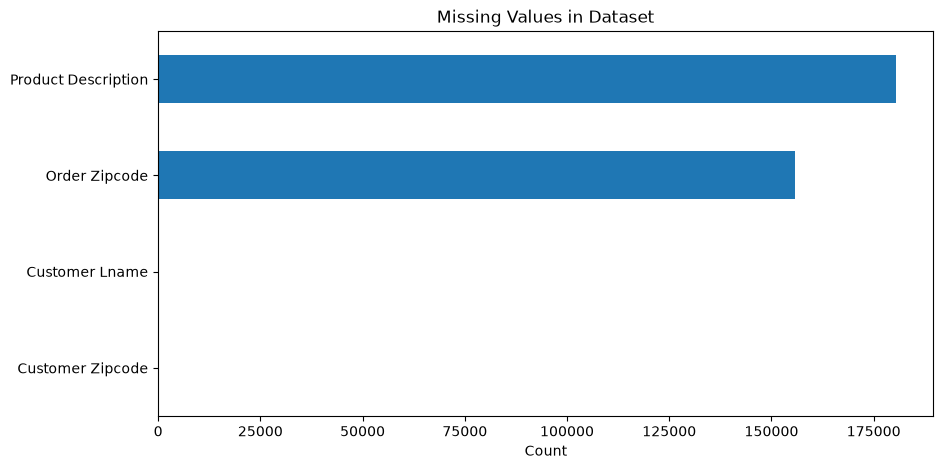

In [15]:
import matplotlib.pyplot as plt

missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(10,5))
missing.sort_values().plot(kind='barh')
plt.title("Missing Values in Dataset")
plt.xlabel("Count")
plt.show()

In [16]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Product Status', 'shipping date (DateOrde

## Target Variable Analysis

In [17]:
# Count late and on-time deliveries
df["Late_delivery_risk"].value_counts()

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

### Visualization of Target Variable

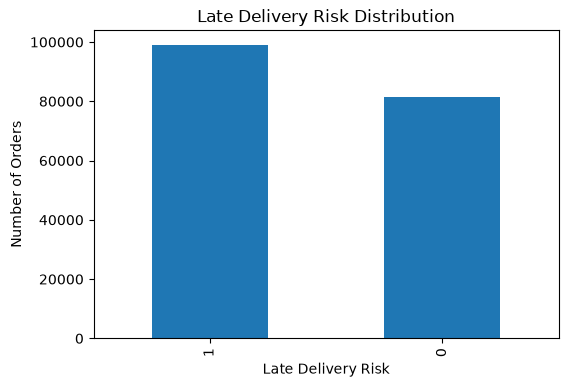

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

df["Late_delivery_risk"].value_counts().plot(kind="bar")

plt.title("Late Delivery Risk Distribution")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Number of Orders")

plt.show()

## Numerical Feature Distribution

In [19]:
# Select numerical columns
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns

numeric_columns

Index(['Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Late_delivery_risk',
       'Category Id', 'Customer Id', 'Customer Zipcode', 'Department Id',
       'Latitude', 'Longitude', 'Order Customer Id', 'Order Id',
       'Order Item Cardprod Id', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Order Zipcode',
       'Product Card Id', 'Product Category Id', 'Product Description',
       'Product Price', 'Product Status'],
      dtype='str')

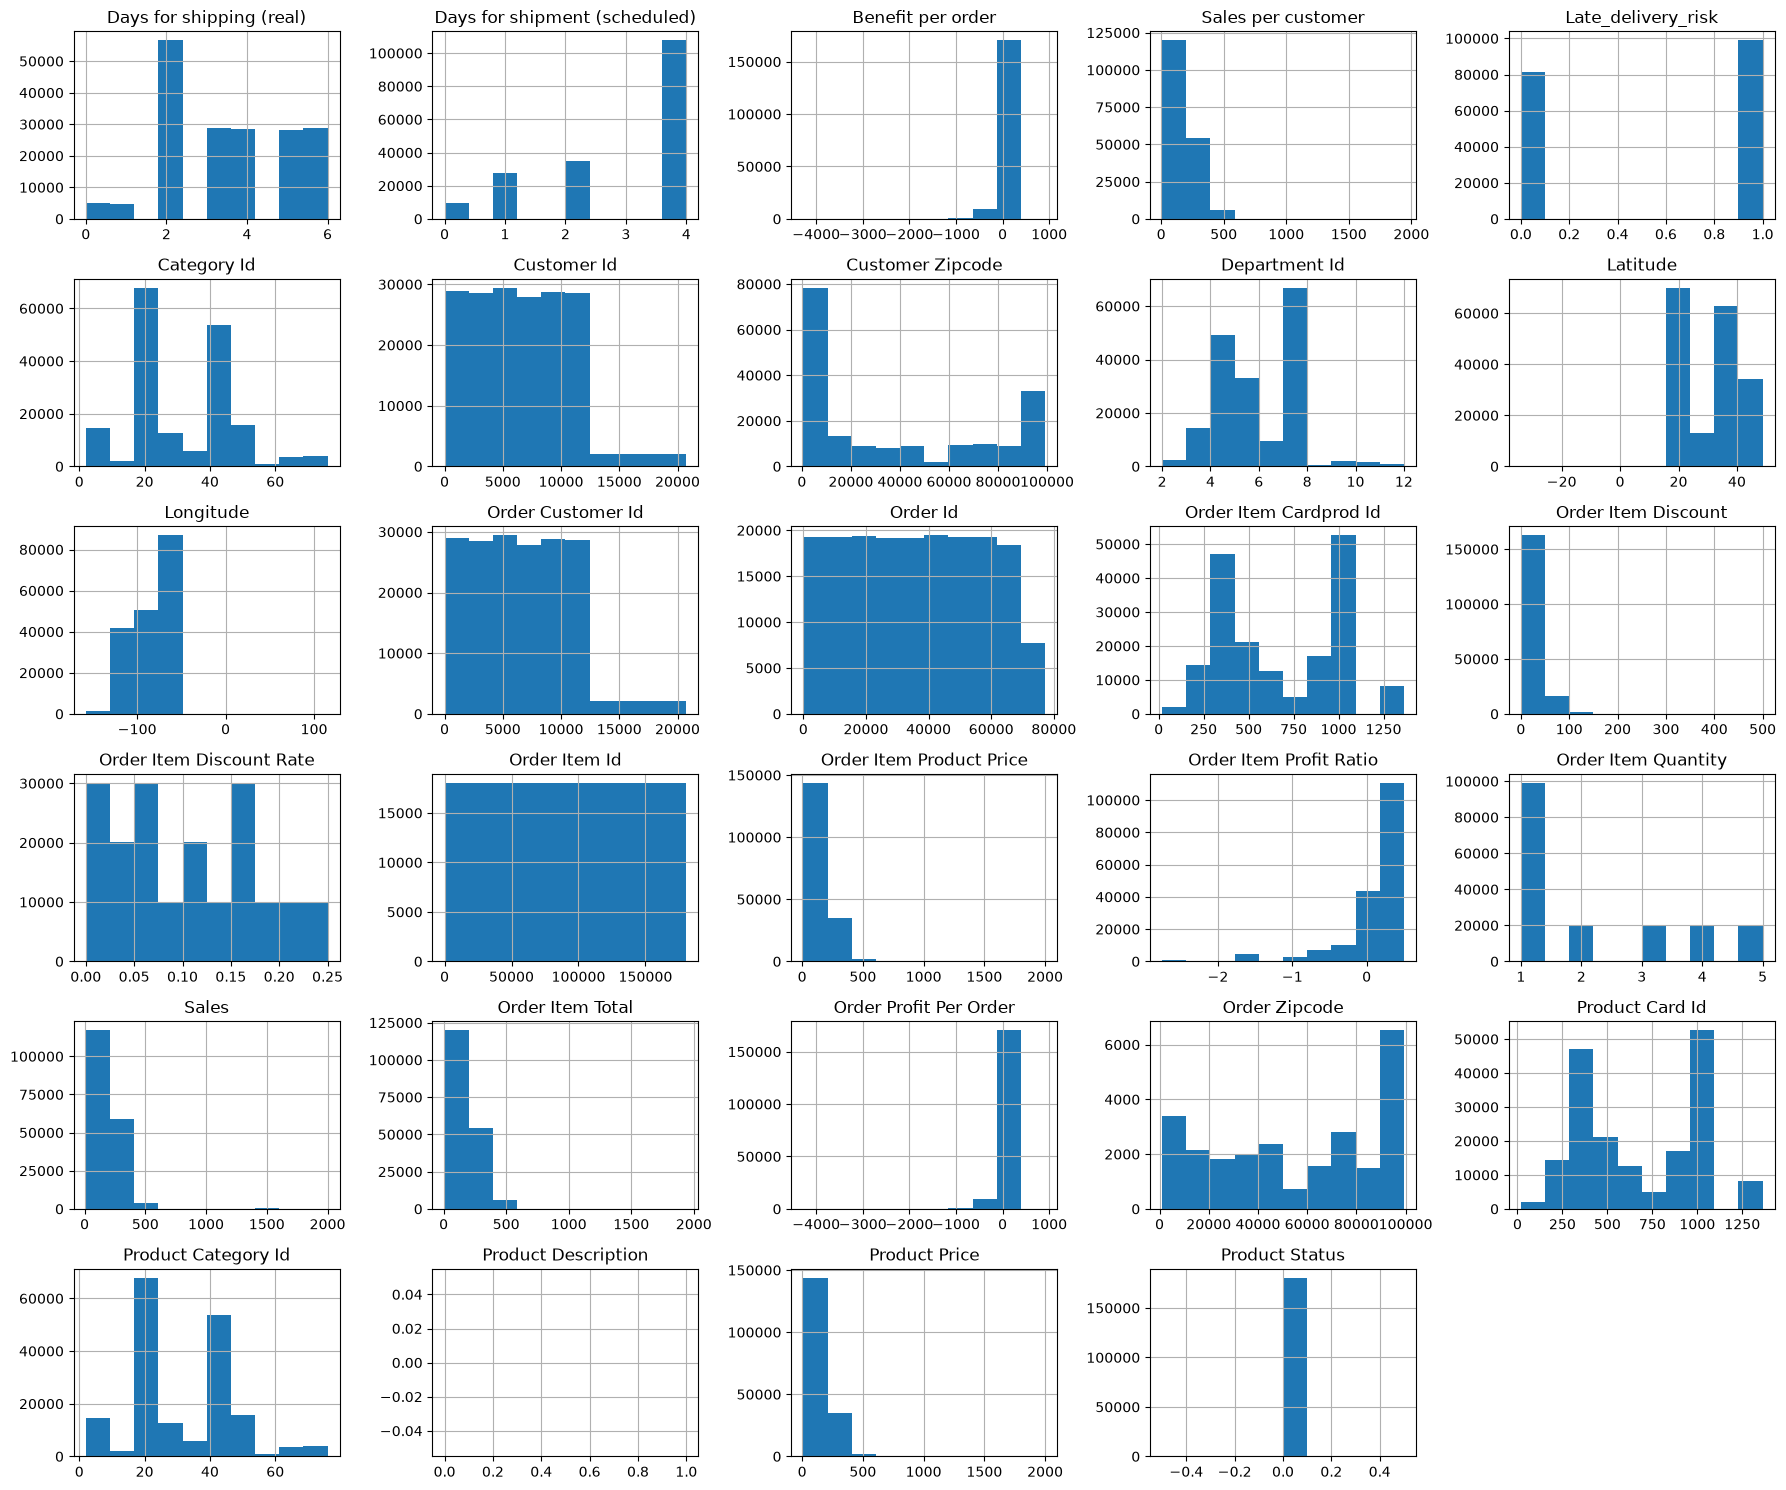

In [20]:
df[numeric_columns].hist(figsize=(18,15))

plt.tight_layout()

plt.show()

## Outlier Analysis

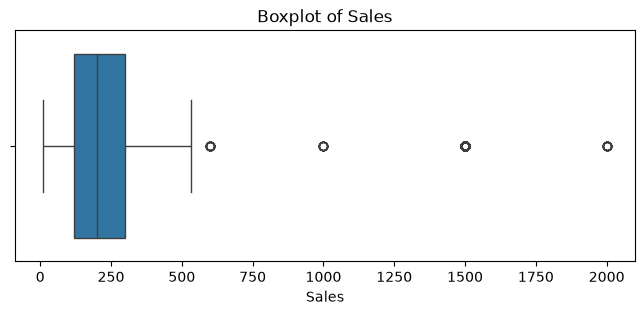

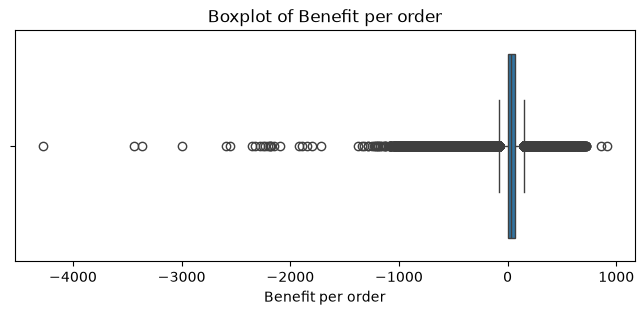

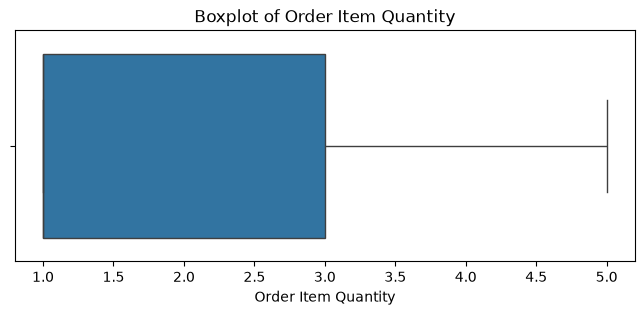

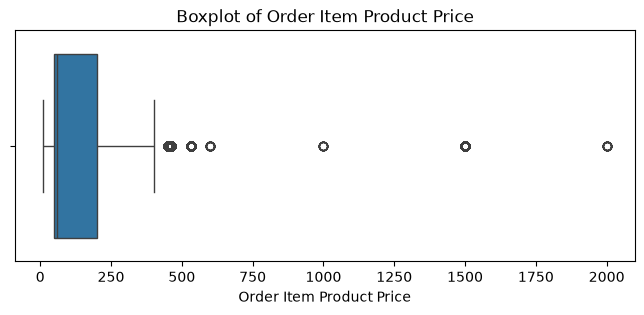

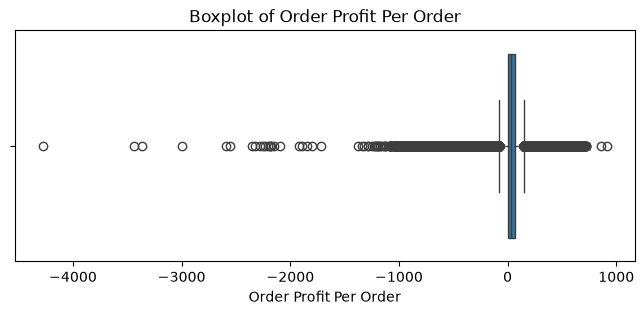

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select important numerical columns
columns = [
    "Sales",
    "Benefit per order",
    "Order Item Quantity",
    "Order Item Product Price",
    "Order Profit Per Order"
]

for col in columns:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## Correlation Heatmap

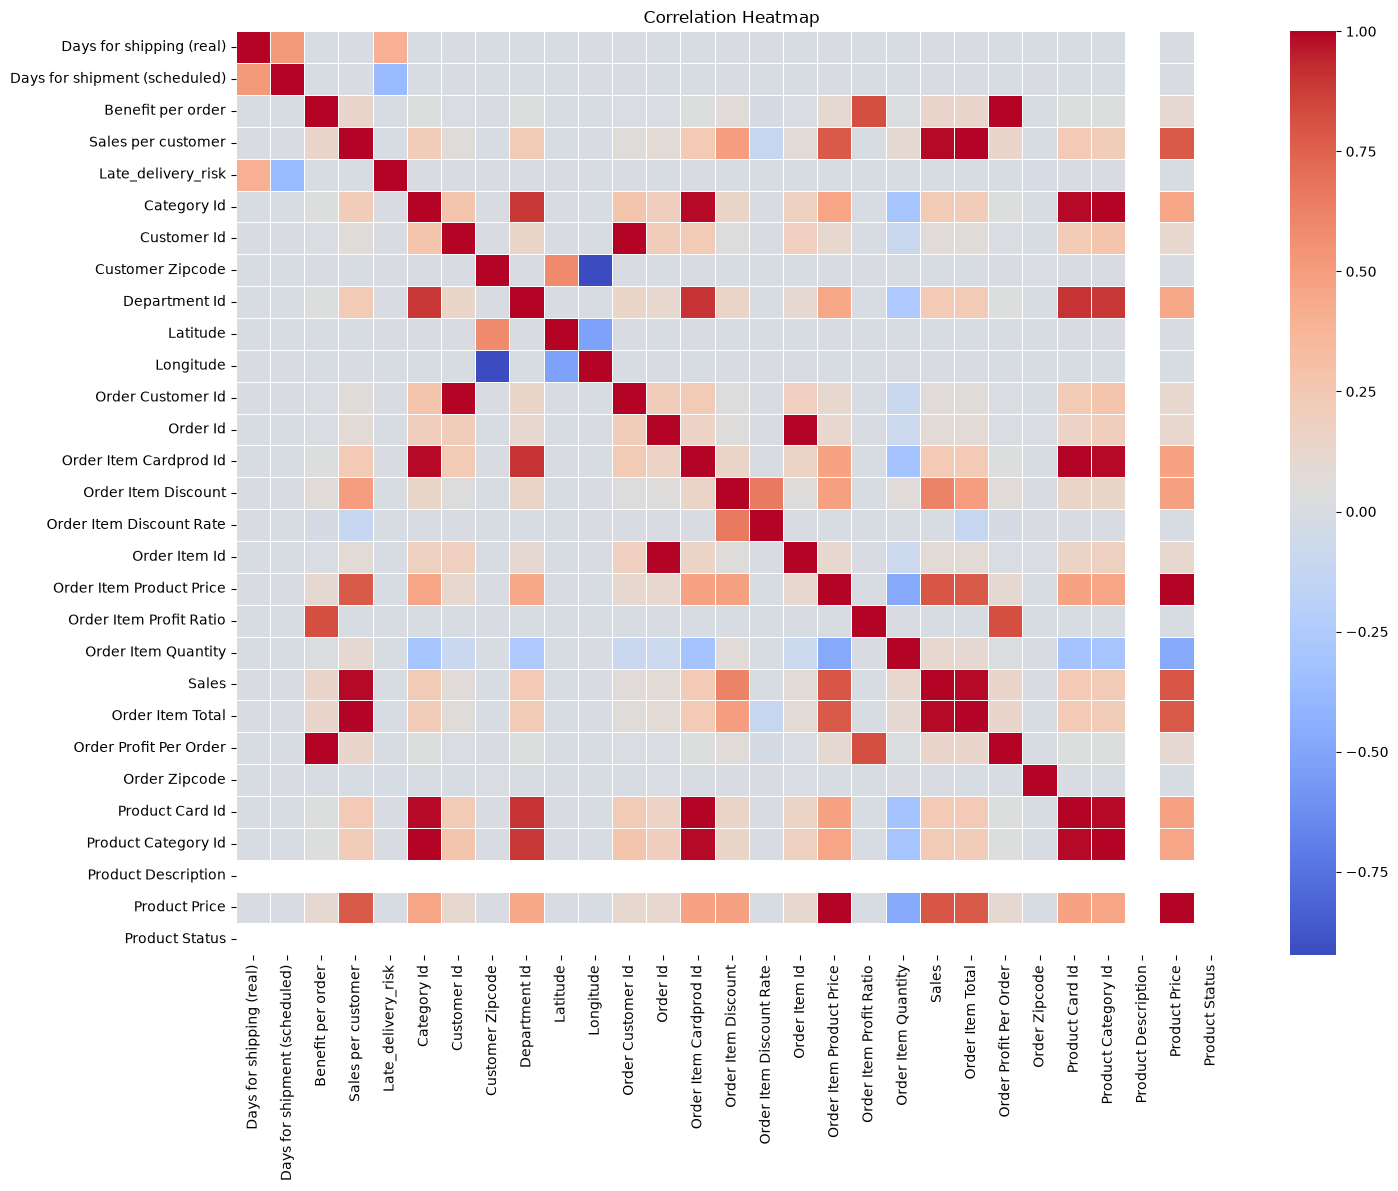

In [22]:
plt.figure(figsize=(16,12))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(corr,
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

## Late Delivery Risk Percentage

In [23]:
risk = df["Late_delivery_risk"].value_counts(normalize=True) * 100

print(risk)

Late_delivery_risk
1    54.829132
0    45.170868
Name: proportion, dtype: float64


## Top Categories

In [25]:
import os

print("Current folder:")
print(os.getcwd())

Current folder:
d:\Late-Delivery-Risk-ML\notebooks


In [26]:
import sys

print(sys.executable)

d:\Late-Delivery-Risk-ML\venv\Scripts\python.exe


In [29]:
import os
print(os.getcwd())

d:\Late-Delivery-Risk-ML\notebooks


In [30]:
import sys
print(sys.executable)

d:\Late-Delivery-Risk-ML\venv\Scripts\python.exe


In [31]:
import os
import sys

print("Current folder:", os.getcwd())
print("Python executable:", sys.executable)

Current folder: d:\Late-Delivery-Risk-ML\notebooks
Python executable: d:\Late-Delivery-Risk-ML\venv\Scripts\python.exe


In [32]:
df.isnull().sum().sort_values(ascending=False)

Product Description              180519
Order Zipcode                    155679
Customer Lname                        8
Customer Zipcode                      3
Days for shipment (scheduled)         0
Sales per customer                    0
Benefit per order                     0
Delivery Status                       0
Late_delivery_risk                    0
Customer City                         0
Customer Country                      0
Category Id                           0
Category Name                         0
Customer Fname                        0
Customer Email                        0
Customer Password                     0
Customer Id                           0
Customer Segment                      0
Customer State                        0
Days for shipping (real)              0
Type                                  0
Department Id                         0
Customer Street                       0
Department Name                       0
Latitude                              0


In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.dtypes

Type                                 str
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                      str
Late_delivery_risk                 int64
Category Id                        int64
Category Name                        str
Customer City                        str
Customer Country                     str
Customer Email                       str
Customer Fname                       str
Customer Id                        int64
Customer Lname                       str
Customer Password                    str
Customer Segment                     str
Customer State                       str
Customer Street                      str
Customer Zipcode                 float64
Department Id                      int64
Department Name                      str
Latitude                         float64
Longitude                        float64
Market          

In [35]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Price,Product Status
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,24840.000000,180519.000000,180519.000000,0.0,180519.000000,180519.0
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,2.127638,203.772096,183.107609,21.974989,55426.132327,692.509764,31.851451,NaN,141.232550,0.0
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,1.453451,132.273077,120.043670,104.433526,31919.279101,336.446807,15.640064,NaN,139.732492,0.0
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,9.990000,7.490000,-4274.979980,1040.000000,19.000000,2.000000,NaN,9.990000,0.0
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,1.000000,119.980003,104.379997,7.000000,23464.000000,403.000000,18.000000,NaN,50.000000,0.0
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,1.000000,199.919998,163.990005,31.520000,59405.000000,627.000000,29.000000,NaN,59.990002,0.0
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,3.000000,299.950012,247.399994,64.800003,90008.000000,1004.000000,45.000000,NaN,199.990005,0.0
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,5.000000,1999.989990,1939.989990,911.799988,99301.000000,1363.000000,76.000000,NaN,1999.989990,0.0


In [37]:
categorical = df.select_dtypes(include=["object", "string"]).columns

print(categorical)

Index(['Type', 'Delivery Status', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Department Name', 'Market',
       'Order City', 'Order Country', 'order date (DateOrders)',
       'Order Region', 'Order State', 'Order Status', 'Product Image',
       'Product Name', 'shipping date (DateOrders)', 'Shipping Mode'],
      dtype='str')


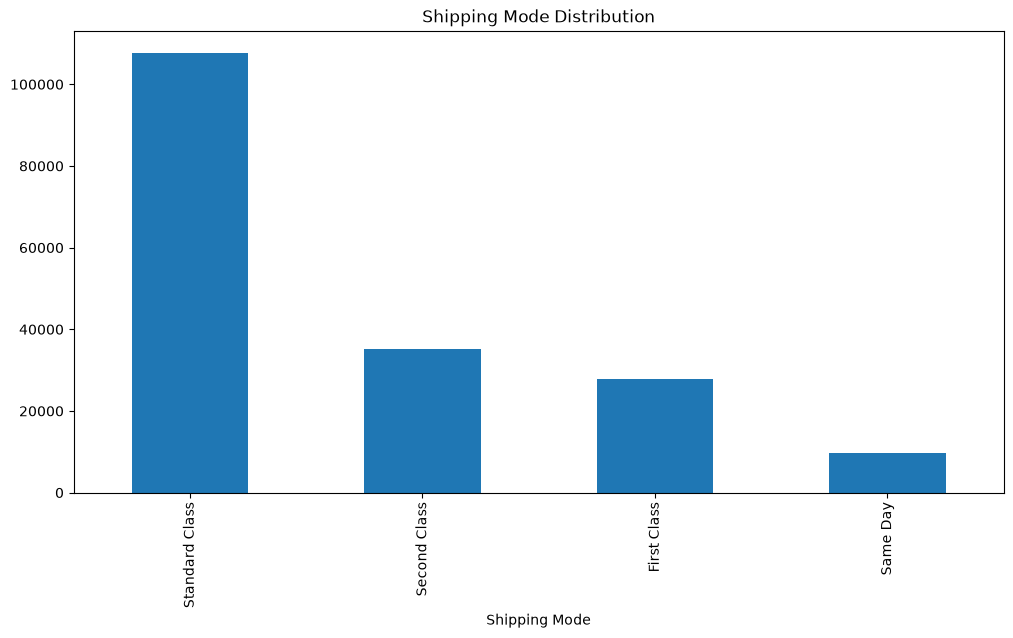

In [38]:
plt.figure(figsize=(12,6))

df["Shipping Mode"].value_counts().plot(kind="bar")

plt.title("Shipping Mode Distribution")

plt.show()

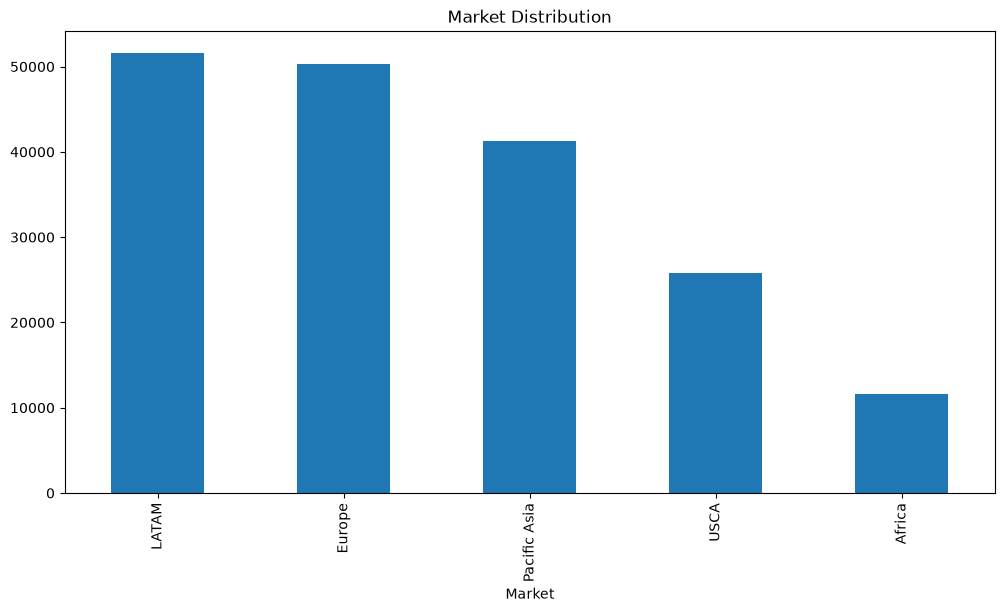

In [39]:
plt.figure(figsize=(12,6))

df["Market"].value_counts().plot(kind="bar")

plt.title("Market Distribution")

plt.show()

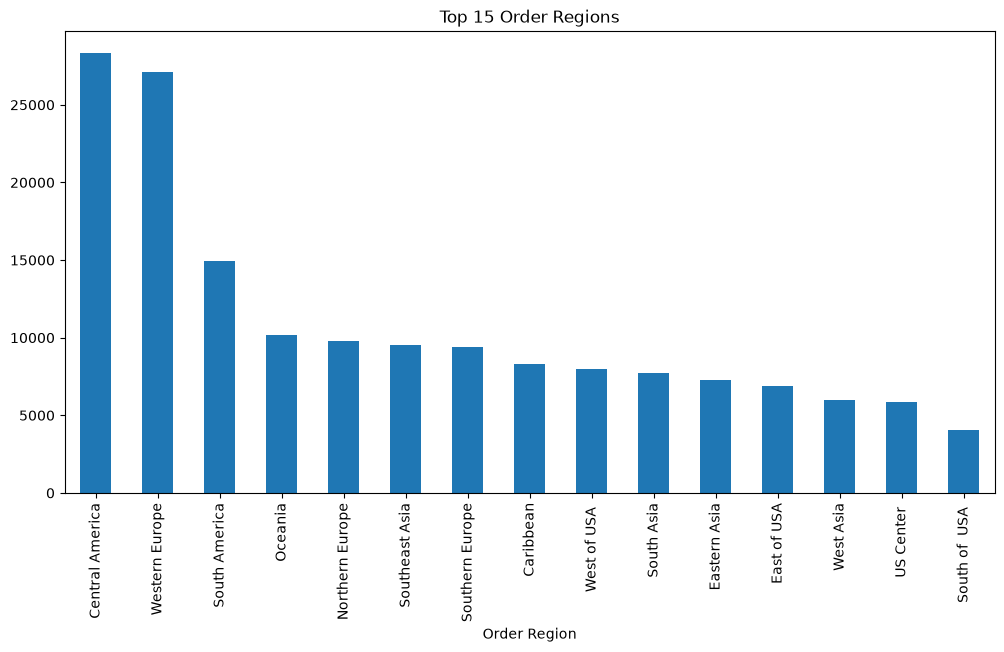

In [40]:
plt.figure(figsize=(12,6))

df["Order Region"].value_counts().head(15).plot(kind="bar")

plt.title("Top 15 Order Regions")

plt.show()

## Class Balance

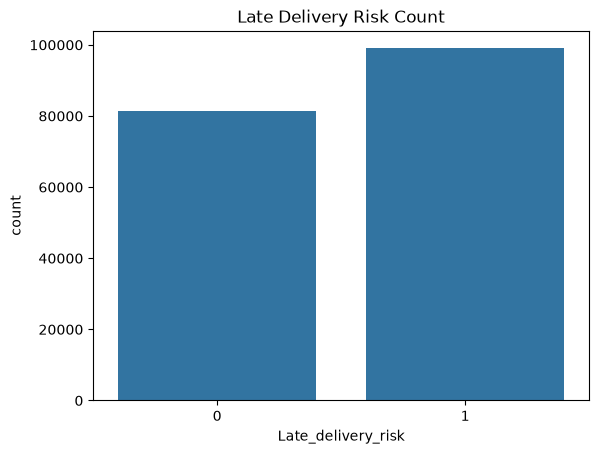

In [41]:
sns.countplot(data=df, x="Late_delivery_risk")

plt.title("Late Delivery Risk Count")

plt.show()

# Data Preprocessing and Leakage Control

## Step 1: Identify Data Leakage Columns

In [42]:
# Total number of columns
print("Total Columns:", len(df.columns))

# Display all column names
for column in df.columns:
    print(column)

Total Columns: 53
Type
Days for shipping (real)
Days for shipment (scheduled)
Benefit per order
Sales per customer
Delivery Status
Late_delivery_risk
Category Id
Category Name
Customer City
Customer Country
Customer Email
Customer Fname
Customer Id
Customer Lname
Customer Password
Customer Segment
Customer State
Customer Street
Customer Zipcode
Department Id
Department Name
Latitude
Longitude
Market
Order City
Order Country
Order Customer Id
order date (DateOrders)
Order Id
Order Item Cardprod Id
Order Item Discount
Order Item Discount Rate
Order Item Id
Order Item Product Price
Order Item Profit Ratio
Order Item Quantity
Sales
Order Item Total
Order Profit Per Order
Order Region
Order State
Order Status
Order Zipcode
Product Card Id
Product Category Id
Product Description
Product Image
Product Name
Product Price
Product Status
shipping date (DateOrders)
Shipping Mode


### Data Leakage Discussion

Some columns contain information that is only available after the delivery outcome is known. These columns must not be used for training because they would cause data leakage and produce unrealistically high model performance.

In [43]:
leakage_columns = [
    "Delivery Status",
    "Days for shipping (real)",
    "shipping date (DateOrders)",
    "Order Status"
]

print("Leakage Columns:")
print(leakage_columns)

Leakage Columns:
['Delivery Status', 'Days for shipping (real)', 'shipping date (DateOrders)', 'Order Status']


## Step 2: Remove Unnecessary Personal Information

In [44]:
personal_columns = [
    "Customer Email",
    "Customer Password",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",
    "Product Image",
    "Product Description"
]

print(personal_columns)

['Customer Email', 'Customer Password', 'Customer Fname', 'Customer Lname', 'Customer Street', 'Product Image', 'Product Description']


## Step 3: Create a Clean Dataset

In [45]:
# Create a copy of the original dataset
df_clean = df.copy()

print("Dataset copied successfully!")

Dataset copied successfully!


## Step 4: Remove Leakage and Unnecessary Columns

In [46]:
columns_to_drop = [
    # Leakage columns
    "Delivery Status",
    "Days for shipping (real)",
    "shipping date (DateOrders)",
    "Order Status",

    # Personal information
    "Customer Email",
    "Customer Password",
    "Customer Fname",
    "Customer Lname",
    "Customer Street",

    # Irrelevant columns
    "Product Image",
    "Product Description"
]

df_clean = df_clean.drop(columns=columns_to_drop)

print("Remaining Columns:", len(df_clean.columns))

Remaining Columns: 42


## Step 5: Verify Dataset

In [47]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 42 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipment (scheduled)  180519 non-null  int64  
 2   Benefit per order              180519 non-null  float64
 3   Sales per customer             180519 non-null  float64
 4   Late_delivery_risk             180519 non-null  int64  
 5   Category Id                    180519 non-null  int64  
 6   Category Name                  180519 non-null  str    
 7   Customer City                  180519 non-null  str    
 8   Customer Country               180519 non-null  str    
 9   Customer Id                    180519 non-null  int64  
 10  Customer Segment               180519 non-null  str    
 11  Customer State                 180519 non-null  str    
 12  Customer Zipcode               180516 non

In [48]:
df_clean.head()

,Type,Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Id,...,Order Profit Per Order,Order Region,Order State,Order Zipcode,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,Shipping Mode
0,DEBIT,4,91.250000,314.640015,0,73,Sporting Goods,Caguas,Puerto Rico,20755,...,91.250000,Southeast Asia,Java Occidental,NaN,1360,73,Smart watch,327.75,0,Standard Class
1,TRANSFER,4,-249.089996,311.359985,1,73,Sporting Goods,Caguas,Puerto Rico,19492,...,-249.089996,South Asia,Rajastán,NaN,1360,73,Smart watch,327.75,0,Standard Class
2,CASH,4,-247.779999,309.720001,0,73,Sporting Goods,San Jose,EE. UU.,19491,...,-247.779999,South Asia,Rajastán,NaN,1360,73,Smart watch,327.75,0,Standard Class
3,DEBIT,4,22.860001,304.809998,0,73,Sporting Goods,Los Angeles,EE. UU.,19490,...,22.860001,Oceania,Queensland,NaN,1360,73,Smart watch,327.75,0,Standard Class
4,PAYMENT,4,134.210007,298.250000,0,73,Sporting Goods,Caguas,Puerto Rico,19489,...,134.210007,Oceania,Queensland,NaN,1360,73,Smart watch,327.75,0,Standard Class


## Step 6: Missing Value Treatment

In [49]:
df_clean.isnull().sum().sort_values(ascending=False)

Order Zipcode                    155679
Customer Zipcode                      3
Benefit per order                     0
Sales per customer                    0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Type                                  0
Days for shipment (scheduled)         0
Customer Id                           0
Customer Country                      0
Customer State                        0
Customer Segment                      0
Department Name                       0
Latitude                              0
Longitude                             0
Department Id                         0
Order City                            0
Order Country                         0
Order Customer Id                     0
order date (DateOrders)               0
Order Id                              0
Order Item Cardprod Id                0
Order Item Discount                   0


## Step 7: Handle Missing Values

In [50]:
missing_values = df_clean.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

Order Zipcode       155679
Customer Zipcode         3
dtype: int64

## Step 8: Fill Missing Values

In [52]:
# Fill numerical columns with median
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill categorical columns with mode
categorical_cols = df_clean.select_dtypes(include=['object', 'string']).columns

for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Missing values handled successfully!")

Missing values handled successfully!


In [53]:
df_clean.isnull().sum().sum()

np.int64(0)

## Step 9: Convert Date Columns

In [56]:
df_clean["order date (DateOrders)"] = pd.to_datetime(
    df_clean["order date (DateOrders)"]
)

In [57]:
df_clean["order date (DateOrders)"].dtype

dtype('<M8[us]')

## Step 10: Feature Engineering

In [58]:
df_clean["Order_Year"] = df_clean["order date (DateOrders)"].dt.year
df_clean["Order_Month"] = df_clean["order date (DateOrders)"].dt.month
df_clean["Order_Day"] = df_clean["order date (DateOrders)"].dt.day
df_clean["Order_Weekday"] = df_clean["order date (DateOrders)"].dt.day_name()

In [59]:
df_clean["order date (DateOrders)"] = pd.to_datetime(
    df_clean["order date (DateOrders)"]
)

print(df_clean["order date (DateOrders)"].dtype)

datetime64[us]


In [60]:
df_clean[[
    "order date (DateOrders)",
    "Order_Year",
    "Order_Month",
    "Order_Day",
    "Order_Weekday"
]].head()

,order date (DateOrders),Order_Year,Order_Month,Order_Day,Order_Weekday
0,2018-01-31 22:56:00,2018,1,31,Wednesday
1,2018-01-13 12:27:00,2018,1,13,Saturday
2,2018-01-13 12:06:00,2018,1,13,Saturday
3,2018-01-13 11:45:00,2018,1,13,Saturday
4,2018-01-13 11:24:00,2018,1,13,Saturday


## Step 11: Feature Selection

In [62]:
# Target variable
target = "Late_delivery_risk"

print("Target Variable:", target)

Target Variable: Late_delivery_risk


In [63]:
# Check target distribution
df_clean[target].value_counts()

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

In [64]:
# Percentage distribution
df_clean[target].value_counts(normalize=True) * 100

Late_delivery_risk
1    54.829132
0    45.170868
Name: proportion, dtype: float64

In [65]:
# Create a copy for cleaning
df_clean = df.copy()

print("Original Shape:", df.shape)
print("Copy Shape:", df_clean.shape)

Original Shape: (180519, 53)
Copy Shape: (180519, 53)


# Step 12: Save Cleaned Dataset

In [70]:
import os

# Create processed folder if it doesn't exist
os.makedirs("../data/processed", exist_ok=True)

# Save cleaned dataset
df_clean.to_csv("../data/processed/DataCoSupplyChain_Clean.csv", index=False)

print("✅ Cleaned dataset saved successfully!")

✅ Cleaned dataset saved successfully!


In [71]:
import os

os.listdir("../data/processed")

['DataCoSupplyChain_Clean.csv']